# 16.7.2 配对预算、失败与迁移范围

## 学习目标与先修知识

在相同场景上计算误差、执行代价、违约和失败比例。

先修：16.7.1 约束决策；14.5 公平模型（model）比较。

## 具体问题

一个学习控制器平均预测更准，却在少数场景求解失败。只报告成功场景的均方误差是否公平？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型对照。

In [2]:
a=np.array([.1,.2,.3]);b=np.array([.2,.1,.5]);print("同一场景的配对绝对误差差：",np.abs(a)-np.abs(b))

同一场景的配对绝对误差差： [-0.1  0.1 -0.2]


## 模型假设

真值、各策略预测、实际输入（input）和失败标记按同一场景索引配对；最终评估不用于选模型或调参。限制值是动作绝对上限；失败情形保留，不能删去再平均。

## 数学解释与推导

对 $N$ 个固定场景，预测 RMSE 为 $\sqrt{N^{-1}\sum(x_i-\hat x_i)^2}$，输入代价为 $N^{-1}\sum u_i^2$，实际违约频率为 $N^{-1}\sum 1(|u_i|>u_{\max})$，失败比例为 $N^{-1}\sum f_i$。这些是不同指标，不宜只按单一 RMSE 排序。若两个方法使用不同隐藏状态（state）、训练预算或备用动作，比较必须明示差异。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def decision_metrics(truth,prediction,inputs,limit,failures):
    actual=np.asarray(truth,dtype=float);forecast=np.asarray(prediction,dtype=float)
    actions=np.asarray(inputs,dtype=float)
    return [float(np.sqrt(np.mean((actual-forecast)**2))),
            float(np.mean(actions**2)),float(np.mean(np.abs(actions)>limit)),
            float(np.mean(np.asarray(failures,dtype=float)))]

## 对照实验

改变已声明的条件并比较曲线与数值。

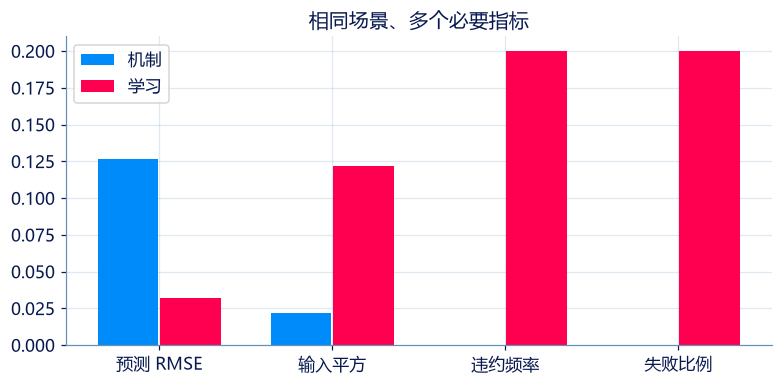

机制 / 学习： [0.12649110640673514, 0.022000000000000002, 0.0, 0.0] [0.031937438845342656, 0.12200000000000003, 0.2, 0.2]


In [4]:
truth=[1.,.8,1.2,1.1,1.4];mechanism=[.9,.9,1.1,1.0,1.2];learned=[1.0,.8,1.19,1.05,1.45]
u_mech=[.1,.2,.1,.2,.1];u_learn=[.2,.4,.1,.6,.2];fail_mech=[0,0,0,0,0];fail_learn=[0,0,0,1,0]
base=decision_metrics(truth,mechanism,u_mech,.5,fail_mech);candidate=decision_metrics(truth,learned,u_learn,.5,fail_learn)
fig,ax=plt.subplots(figsize=(7,3.4));labels=["预测 RMSE","输入平方","违约频率","失败比例"];xx=np.arange(4)
ax.bar(xx-.18,base,width=.35,label="机制",color=BLUE);ax.bar(xx+.18,candidate,width=.35,label="学习",color=PINK);ax.set_xticks(xx,labels);ax.set(title="相同场景、多个必要指标");ax.legend();plt.show()
print("机制 / 学习：",base,candidate)

## 结果解释

学习候选在这张人工表的预测误差较小，但动作上限和求解失败记录更差；不能省略失败场景后只报告成功预测。没有独立重复时不估计一般人群收益。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
np.testing.assert_allclose(base[0],np.sqrt(np.mean((np.asarray(truth)-mechanism)**2)))
np.testing.assert_allclose(candidate[2:], [.2,.2])
assert len(truth)==len(mechanism)==len(learned)
print("手算 RMSE、违约和失败分母核验通过。")

手算 RMSE、违约和失败分母核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/16-07-%E6%A8%A1%E5%9E%8B%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%BA%A6%E6%9D%9F%E5%86%B3%E7%AD%96/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：公平配对比较

两策略在相同测试场景比较，哪项必须保留？

- **A.** 只保留成功场景。
- **B.** 学习方法额外读取隐藏真状态（state）。
- **C.** 每个场景的预测、实际输入（input）、违约和失败。
- **D.** 只报告最小一次误差。

[作答：公平配对比较](http://127.0.0.1:8000/chapters/16-07-%E6%A8%A1%E5%9E%8B%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%BA%A6%E6%9D%9F%E5%86%B3%E7%AD%96/practice/?question=p16-paired-budget)

### 第 2 题 · 单项选择题：预测更准是否更安全

候选 RMSE 更低，但动作越界和求解失败更多，何种结论成立？

- **A.** 候选必在所有决策指标更好。
- **B.** 只要 RMSE 低就忽略失败。
- **C.** 机制基线一定没有价值。
- **D.** 当前表中预测误差更低；决策风险证据须单列。

[作答：预测更准是否更安全](http://127.0.0.1:8000/chapters/16-07-%E6%A8%A1%E5%9E%8B%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%BA%A6%E6%9D%9F%E5%86%B3%E7%AD%96/practice/?question=p16-rmse-not-safety)

### 第 3 题 · Python 计算题：统一条件下的决策指标

给定一批配对测试的真实状态（state）、预测、实际动作和失败标志，返回 RMSE、动作平方均值、动作越界率及失败率。

**函数与代码模板**

```python
def solve(
    truth: list[float],
    prediction: list[float],
    inputs: list[float],
    limit: float,
    failures: list[bool],
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `truth` | `list[float]` | 同一批测试的真实后继状态。 | U |
| `prediction` | `list[float]` | 相应预测后继状态。 | U |
| `inputs` | `list[float]` | 实际执行动作。 | U |
| `limit` | `float` | 动作绝对上限。 | U |
| `failures` | `list[bool]` | 每场景求解失败标志。 | 1 |

**返回值**

直接返回 metrics（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `metrics` | `list[float]` | RMSE、动作平方均值、越界率、失败率。 | 混合 |

**计算规则**

四项依次为预测 RMSE、实际动作平方均值、实际动作绝对值超过 limit 的比例、求解失败比例；所有场景均保留。

**约束与边界**

- truth、prediction、inputs、failures 四个列表等长且非空，长度≤100；limit 是全部场景共用的非负标量上限；全部数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| truth | 同一批测试的真实后继状态。 | [1.0, 2.0] | U |
| prediction | 相应预测后继状态。 | [1.0, 1.0] | U |
| inputs | 实际执行动作。 | [0.0, 2.0] | U |
| limit | 动作绝对上限。 | 1 | U |
| failures | 每场景求解失败标志。 | [False, True] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
truth = [1.0, 2.0]
prediction = [1.0, 1.0]
inputs = [0.0, 2.0]
limit = 1.0
failures = [False, True]

result = solve(truth, prediction, inputs, limit, failures)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| metrics | RMSE、动作平方均值、越界率、失败率。 | [0.7071067811865476, 2.0, 0.5, 0.5] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.7071067811865476, 2.0, 0.5, 0.5]
```

**样例解释**

首例误差为0和-1，RMSE=√(1/2)；两个动作中一个越界、一个求解失败。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：统一条件下的决策指标](http://127.0.0.1:8000/chapters/16-07-%E6%A8%A1%E5%9E%8B%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%BA%A6%E6%9D%9F%E5%86%B3%E7%AD%96/practice/?question=p16-paired-metrics)

### 第 4 题 · Python 计算题：不要遗漏失败场景

即使某次优化失败，也应在完整配对样本中计算失败率与其他已定义指标。

**函数与代码模板**

```python
def solve(
    truth: list[float],
    prediction: list[float],
    inputs: list[float],
    limit: float,
    failures: list[bool],
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `truth` | `list[float]` | 完整测试场景真实值。 | U |
| `prediction` | `list[float]` | 对应预测。 | U |
| `inputs` | `list[float]` | 记录的实际或备用动作。 | U |
| `limit` | `float` | 动作上限。 | U |
| `failures` | `list[bool]` | 求解失败标志。 | 1 |

**返回值**

直接返回 metrics（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `metrics` | `list[float]` | 预测 RMSE、动作平方均值、越界率、失败率。 | 混合 |

**计算规则**

四项依次为预测 RMSE、实际动作平方均值、实际动作绝对值超过 limit 的比例、求解失败比例；所有场景均保留。

**约束与边界**

- truth、prediction、inputs、failures 四个列表等长且非空，长度≤100；limit 是全部场景共用的非负标量上限；全部数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| truth | 完整测试场景真实值。 | [1.0, 1.0] | U |
| prediction | 对应预测。 | [1.0, 1.0] | U |
| inputs | 记录的实际或备用动作。 | [0.0, 0.0] | U |
| limit | 动作上限。 | 1 | U |
| failures | 求解失败标志。 | [True, False] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
truth = [1.0, 1.0]
prediction = [1.0, 1.0]
inputs = [0.0, 0.0]
limit = 1.0
failures = [True, False]

result = solve(truth, prediction, inputs, limit, failures)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| metrics | 预测 RMSE、动作平方均值、越界率、失败率。 | [0.0, 0.0, 0.0, 0.5] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.0, 0.0, 0.0, 0.5]
```

**样例解释**

首例预测误差为0，但一半场景求解失败；RMSE 不能代替失败率。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：不要遗漏失败场景](http://127.0.0.1:8000/chapters/16-07-%E6%A8%A1%E5%9E%8B%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%BA%A6%E6%9D%9F%E5%86%B3%E7%AD%96/practice/?question=p16-failure-rate)

**进一步阅读**

[Boyd 的优化教材](https://web.stanford.edu/~boyd/cvxbook/)提供约束目标基础；评价指标与场景是课程教学设计。